## For sample train data

In [1]:
import json
import os
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

dataset_path = '../FigureQA_Dataset/sample_train1'
annotations_file = os.path.join(dataset_path, 'annotations.json')
qa_file = os.path.join(dataset_path, 'qa_pairs.json')
images_dir = os.path.join(dataset_path, 'png')

with open(annotations_file, 'r') as f:
    annotations = json.load(f)

with open(qa_file, 'r') as f:
    qa_pairs_data = json.load(f)['qa_pairs']

def get_annotations(idx):
    return annotations[idx]

def get_qa_pairs(idx):
    return [qa for qa in qa_pairs_data if qa['image_index'] == idx]


def get_original_json_data(idx):
    original_annotation = annotations[idx]
    
    original_qa_list = [qa for qa in qa_pairs_data if qa['image_index'] == idx]
    
    full_original_data = {
        "original_annotation": original_annotation,
        "original_qa_pairs": original_qa_list
    }
    
    return full_original_data


def explore_chart(idx):
    """Visualizes the chart, its annotations, and its QA pairs."""
    img_path = os.path.join(images_dir, f"{idx}.png")
    if os.path.exists(img_path):
        plt.figure(figsize=(15, 8))
        img = mpimg.imread(img_path)
        plt.imshow(img)
        plt.title(f"Image Index: {idx}", fontsize=15)
        plt.axis('off')
        plt.show()
    print(json.dumps(get_original_json_data(idx), indent=4))


def get_good_qa(idx):
    original_qa_list = [qa for qa in qa_pairs_data if qa['image_index'] == idx]
    for i in original_qa_list:
        print("Question: ", i['question_string'])
        ans = "Yes" if i['answer'] == 1 else "No"
        print("Answer: ", ans)
        print("-")
        
    


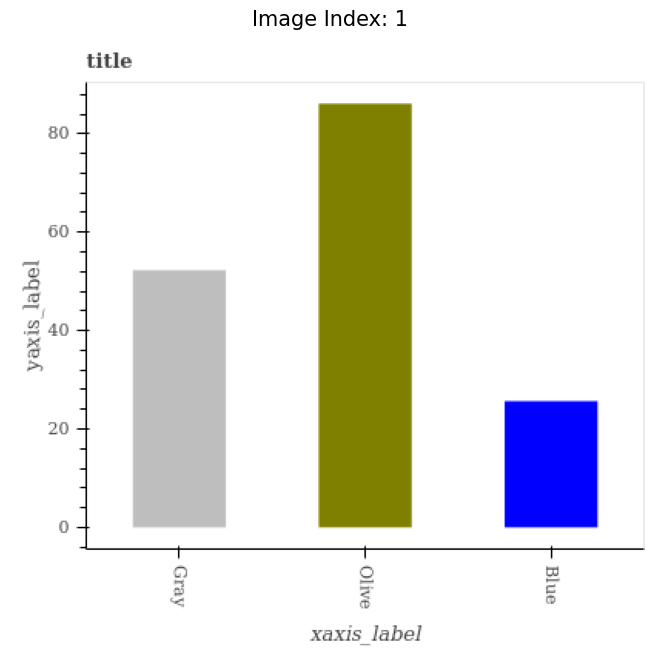

{
    "original_annotation": {
        "models": [
            {
                "name": "bars",
                "labels": [
                    "Gray",
                    "Olive",
                    "Blue"
                ],
                "width": 0.5,
                "colors": [
                    "#BEBEBE",
                    "#808000",
                    "#0000FF"
                ],
                "bboxes": [
                    {
                        "y": 153,
                        "x": 79,
                        "w": 60,
                        "h": 167
                    },
                    {
                        "y": 45,
                        "x": 200,
                        "w": 60,
                        "h": 275
                    },
                    {
                        "y": 238,
                        "x": 321,
                        "w": 60,
                        "h": 82
                    }
                ],
                "y": [


In [2]:
explore_chart(1)

In [3]:
get_good_qa(1)

Question:  Is Blue the minimum?
Answer:  Yes
-
Question:  Is Olive the maximum?
Answer:  Yes
-
Question:  Is Olive the minimum?
Answer:  No
-
Question:  Is Blue the maximum?
Answer:  No
-
Question:  Is Olive greater than Blue?
Answer:  Yes
-
Question:  Is Blue less than Olive?
Answer:  Yes
-
Question:  Is Blue greater than Olive?
Answer:  No
-
Question:  Is Olive less than Blue?
Answer:  No
-
Question:  Is Gray the high median?
Answer:  Yes
-
Question:  Is Gray the low median?
Answer:  Yes
-
Question:  Is Blue the high median?
Answer:  No
-
Question:  Is Blue the low median?
Answer:  No
-


In [4]:
import json
import os

def convert_to_donut_format_robust(annotations_list, target_folder):
    """
    Robust conversion that handles missing 'labels' keys and string values.
    """
    output_path = os.path.join(target_folder, "metadata.jsonl")
    print(f"Generating metadata for {len(annotations_list)} images...")
    
    with open(output_path, 'w') as f:
        for ann in annotations_list:
            
            if not ann.get('models'):
                continue
                
            chart_model = ann['models'][0]
            
            if 'labels' in chart_model:
                labels = chart_model['labels']
            elif 'x' in chart_model:
                labels = chart_model['x']
            if 'y' in chart_model:
                values = chart_model['y']
            else:
                continue
            
            if labels is None:
                labels = [str(i) for i in range(len(values))]
            
            data_points = []
            for i in range(min(len(labels), len(values))):
                label = labels[i]
                val = values[i]
                
                try:
                    numeric_val = float(val)
                except (ValueError, TypeError):
                    numeric_val = 0.0
                    
                data_points.append({
                    "label": str(label), 
                    "value": round(numeric_val, 2)
                })

            gt_parse = {
                "chart_type": ann.get('type', 'unknown'),
                "data": data_points
            }
            
            img_filename = f"{ann['image_index']}.png"
            line = {
                "file_name": img_filename,
                "ground_truth": json.dumps({"gt_parse": gt_parse})
            }
            
            f.write(json.dumps(line) + "\n")
            
    print(f"✅ Success! Robust metadata saved at: {output_path}")

spectra_path = "/Users/aryangahlot/Desktop/Coding/AI-ML/Spectra"
convert_to_donut_format_robust(annotations, spectra_path)

Generating metadata for 1000 images...
✅ Success! Robust metadata saved at: /Users/aryangahlot/Desktop/Coding/AI-ML/Spectra/metadata.jsonl


In [ ]:
import json
import os
import torch
from datasets import Dataset, Image
from transformers import DonutProcessor, VisionEncoderDecoderModel, Seq2SeqTrainingArguments, Seq2SeqTrainer

print("🛠️ Initializing Lazy-Load Training Pipeline...")

base_path = '../FigureQA_Dataset/sample_train1'
metadata_path = os.path.join(base_path, 'metadata.jsonl')
images_folder = os.path.join(base_path, 'png')

data_entries = []
with open(metadata_path, 'r') as f:
    for line in f:
        entry = json.loads(line)
        entry['image'] = os.path.join(images_folder, entry['file_name'])
        data_entries.append(entry)

dataset = Dataset.from_list(data_entries)
dataset = dataset.cast_column("image", Image())

processor = DonutProcessor.from_pretrained("naver-clova-ix/donut-base")
processor.image_processor.size = {"height": 1280, "width": 960} 

new_special_tokens = ["<s_chart_qa>", "</s_chart_qa>"]
processor.tokenizer.add_special_tokens({"additional_special_tokens": new_special_tokens})


def transform_fn(batch):
    
    images = [x.convert("RGB") for x in batch["image"]]
    pixel_values = processor(images, return_tensors="pt").pixel_values

    targets = [f"<s_chart_qa>{gt}</s_chart_qa>" for gt in batch["ground_truth"]]
    labels = processor.tokenizer(
        targets,
        add_special_tokens=False,
        max_length=512,
        padding="max_length",
        truncation=True,
        return_tensors="pt"
    ).input_ids

    labels[labels == processor.tokenizer.pad_token_id] = -100
    
    return {"pixel_values": pixel_values, "labels": labels}

dataset.set_transform(transform_fn)
print("✅ Dataset set to Lazy Mode (No pre-computation needed).")

model = VisionEncoderDecoderModel.from_pretrained("naver-clova-ix/donut-base")
model.decoder.resize_token_embeddings(len(processor.tokenizer))
model.config.decoder_start_token_id = processor.tokenizer.convert_tokens_to_ids("<s_chart_qa>")
model.config.pad_token_id = processor.tokenizer.pad_token_id
model.config.vocab_size = model.config.decoder.vocab_size
model.config.encoder.image_size = [1280, 960] # Match processor

device = "mps" if torch.backends.mps.is_available() else "cpu"
model.to(device)

training_args = Seq2SeqTrainingArguments(
    output_dir="./stem_sight_model_v1",
    num_train_epochs=3,
    learning_rate=2e-5,
    per_device_train_batch_size=1, 
    gradient_accumulation_steps=8,
    dataloader_num_workers=0, 
    gradient_checkpointing=True, 
    logging_steps=5, 
    save_total_limit=1,
    fp16=False, 
    remove_unused_columns=False, 
    report_to="none"
)

trainer = Seq2SeqTrainer(
    model=model,
    args=training_args,
    train_dataset=dataset, 
)

print(f"🚀 Starting Training on {device}...")
trainer.train()

/Users/aryangahlot/.pyenv/versions/tfenv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


🛠️ Initializing Lazy-Load Training Pipeline...


The image processor of type `DonutImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. 


✅ Dataset set to Lazy Mode (No pre-computation needed).


Loading weights: 100%|█| 484/484 [00:00<00:00, 1666.95it/s, Materializing param=encoder.encoder.layers.3.blocks.
The tied weights mapping and config for this model specifies to tie decoder.model.decoder.embed_tokens.weight to decoder.lm_head.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
The new embeddings will be initialized from a multivariate normal distribution that has old embeddings' mean and covariance. As described in this article: https://nlp.stanford.edu/~johnhew/vocab-expansion.html. To disable this, use `mean_resizing=False`
The new lm_head weights will be initialized from a multivariate normal distribution that has old embeddings' mean and covariance. As described in this article: https://nlp.stanford.edu/~johnhew/vocab-expansion.html. To disable this, use `mean_resizing=False`


🚀 Starting Training on mps...


/Users/aryangahlot/.pyenv/versions/tfenv/lib/python3.10/site-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)
`use_cache=True` is incompatible with gradient checkpointing`. Setting `use_cache=False`...


Step,Training Loss
5,39.857513
10,24.885057
15,21.031561
20,17.067975
25,13.385222
30,12.675267
35,11.067305
40,10.441199
45,8.655729
50,8.163565


Writing model shards: 100%|███████████████████████████████████████████████████████| 1/1 [00:00<00:00,  1.48it/s]


TrainOutput(global_step=300, training_loss=7.058731517791748, metrics={'train_runtime': 6451.6006, 'train_samples_per_second': 0.372, 'train_steps_per_second': 0.047, 'total_flos': 7.50458796244992e+18, 'train_loss': 7.058731517791748, 'epoch': 3.0})

In [ ]:
import torch
from transformers import DonutProcessor, VisionEncoderDecoderModel

trained_model_path = "./stem_sight_model_v1" 

print(f"📂 Loading weights from {trained_model_path}...")


model = VisionEncoderDecoderModel.from_pretrained("naver-clova-ix/donut-base")


checkpoint_path = f"{trained_model_path}/checkpoint-300" 
if os.path.exists(checkpoint_path):
    print(f"Found checkpoint: {checkpoint_path}")
    model = VisionEncoderDecoderModel.from_pretrained(checkpoint_path)
else:
    print("⚠️ specific checkpoint not found, trying root folder...")
    model = VisionEncoderDecoderModel.from_pretrained(trained_model_path)

processor = DonutProcessor.from_pretrained("naver-clova-ix/donut-base")
processor.image_processor.size = {"height": 1280, "width": 960}
model.config.encoder.image_size = [1280, 960]

device = "mps" if torch.backends.mps.is_available() else "cpu"
model.to(device)
model.eval()

print("✅ Model loaded successfully!")

📂 Loading weights from ./stem_sight_model_v1...


Loading weights: 100%|█| 484/484 [00:00<00:00, 1950.42it/s, Materializing param=encoder.encoder.layers.3.blocks.
The tied weights mapping and config for this model specifies to tie decoder.model.decoder.embed_tokens.weight to decoder.lm_head.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning


Found checkpoint: ./stem_sight_model_v1/checkpoint-300


Loading weights: 100%|█| 483/483 [00:00<00:00, 1684.72it/s, Materializing param=encoder.encoder.layers.3.blocks.


✅ Model loaded successfully!


In [ ]:
import re
import json
import torch
from PIL import Image

dataset.reset_format()


def robust_json_to_speech(raw_text):
    try:
        
        chart_type_match = re.search(r'(vbar_categorical|line|bar|pie|dot)', raw_text)
        chart_type = chart_type_match.group(0) if chart_type_match else "chart"
        
       
        pattern = r'\{\s*"label":\s*"([^"]+)",\s*"value":\s*([0-9\.]+)\s*\}'
        matches = re.findall(pattern, raw_text)
        
        if not matches:
            return "I can see the graph structure, but the data points are fuzzy."

        labels = [m[0] for m in matches]
        values = [float(m[1]) for m in matches]
        
        max_val = max(values)
        min_val = min(values)
        max_label = labels[values.index(max_val)]
        min_label = labels[values.index(min_val)]
        
        summary = (
            f"This is a {chart_type}. "
            f"It contains {len(values)} data points, including {', '.join(labels[:3])}, and others. "
            f"The highest value is {max_val} for {max_label}, "
            f"and the lowest is {min_val} for {min_label}."
        )
        return summary

    except Exception as e:
        return f"I am having trouble reading this graph. (Error: {str(e)})"

test_sample = dataset[15] 
image = test_sample['image'].convert("RGB") 

print("------------------------------------------------")
print(f"🖼️  Scanning Image: {test_sample['file_name']}")

device = "mps" if torch.backends.mps.is_available() else "cpu"
model.to(device)

pixel_values = processor(image, return_tensors="pt").pixel_values.to(device)
decoder_input_ids = processor.tokenizer(
    "<s_chart_qa>", add_special_tokens=False, return_tensors="pt"
).input_ids.to(device)

outputs = model.generate(
    pixel_values,
    decoder_input_ids=decoder_input_ids,
    max_length=512,
    early_stopping=True,
    pad_token_id=processor.tokenizer.pad_token_id,
    eos_token_id=processor.tokenizer.eos_token_id,
    use_cache=True,
    num_beams=1,
    bad_words_ids=[[processor.tokenizer.unk_token_id]],
    return_dict_in_generate=True,
)

sequence = processor.batch_decode(outputs.sequences)[0]
sequence = sequence.replace(processor.tokenizer.eos_token, "").replace(processor.tokenizer.pad_token, "")
raw_output = re.sub(r"<.*?>", "", sequence, count=1).strip()

print(f"📄 Raw Output (Broken JSON): {raw_output[:100]}...")

audio_text = robust_json_to_speech(raw_output)

print("\n🔊 STEM SIGHT AUDIO:")
print("---------------------")
print(f"\"{audio_text}\"")
print("---------------------")

------------------------------------------------
🖼️  Scanning Image: 15.png
📄 Raw Output (Broken JSON): : "vbar_categorical", "data": [{"label": "Cyan", "value": 99.0}, {"label": "Peru", "value": 99.0}, {...

🔊 STEM SIGHT AUDIO:
---------------------
"This is a vbar_categorical. It contains 7 data points, including Cyan, Peru, Cornflower, and others. The highest value is 99.0 for Cyan, and the lowest is 99.0 for Cyan."
---------------------
